# 01 — Analyse exploratoire (EDA)

Objectif : comprendre les ventes **avant** de modéliser, et justifier les choix de features
(décalages 7/14/28/364, jours fériés, promotions, jours de paie).

> Utilise Favorita si `data/raw/train.csv` existe, sinon des données synthétiques (les conclusions ne valent alors que pour le test du notebook).

In [5]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

RAW = Path("C:/Users/asus/Desktop/Demand forecasting project/data/raw")
KEY = ["store_nbr", "family"]
FAMILIES = ["GROCERY I", "BEVERAGES", "PRODUCE", "CLEANING", "DAIRY", "BREAD/BAKERY"]
N_STORES = 6
START = "2015-01-01"



In [6]:
# --- ventes
train = pd.read_csv(RAW / "train.csv", parse_dates=["date"])
train = train[(train["family"].isin(FAMILIES)) & (train["date"] >= START)]
top_stores = train.groupby("store_nbr")["sales"].sum().nlargest(N_STORES).index
train = train[train["store_nbr"].isin(top_stores)][["date", "store_nbr", "family", "sales", "onpromotion"]]



In [7]:
train.head(3)

,date,store_nbr,family,sales,onpromotion
1298025,2015-01-01,3,BEVERAGES,0.0,0
1298027,2015-01-01,3,BREAD/BAKERY,0.0,0
1298029,2015-01-01,3,CLEANING,0.0,0


In [8]:
# --- calendrier complet (pas de trou par série, ex. 25/12 absent chez Favorita -> rempli à 0)
full_dates = pd.date_range(train["date"].min(), train["date"].max(), freq="D")
idx = pd.MultiIndex.from_product(
    [sorted(train["store_nbr"].unique()), sorted(train["family"].unique()), full_dates], names=KEY + ["date"])
df = train.set_index(KEY + ["date"]).reindex(idx)
df[["sales", "onpromotion"]] = df[["sales", "onpromotion"]].fillna(0.0)
df = df.reset_index().sort_values(KEY + ["date"]).reset_index(drop=True)



In [9]:
df.head(3)

,store_nbr,family,date,sales,onpromotion
0,3,BEVERAGES,2015-01-01,0.0,0.0
1,3,BEVERAGES,2015-01-02,5021.0,1.0
2,3,BEVERAGES,2015-01-03,5099.0,3.0


In [10]:
# --- jours fériés nationaux effectivement chômés (holidays_events.csv)
h = pd.read_csv(RAW / "holidays_events.csv", parse_dates=["date"])
h = h[(h["locale"] == "National") & (~h["transferred"].astype(bool)) & (h["type"] != "Work Day")]
holidays = pd.DatetimeIndex(sorted(h["date"].unique()))



In [12]:
print("séries :", df.groupby(KEY).ngroups, "|", df.date.min().date(), "→", df.date.max().date())
print(len(holidays), "jours fériés nationaux")
df.head()

séries : 36 | 2015-01-01 → 2017-08-15
155 jours fériés nationaux


,store_nbr,family,date,sales,onpromotion
0,3,BEVERAGES,2015-01-01,0.0,0.0
1,3,BEVERAGES,2015-01-02,5021.0,1.0
2,3,BEVERAGES,2015-01-03,5099.0,3.0
3,3,BEVERAGES,2015-01-04,6126.0,1.0
4,3,BEVERAGES,2015-01-05,4591.0,4.0


## 1. Vue d'ensemble : niveau et tendance

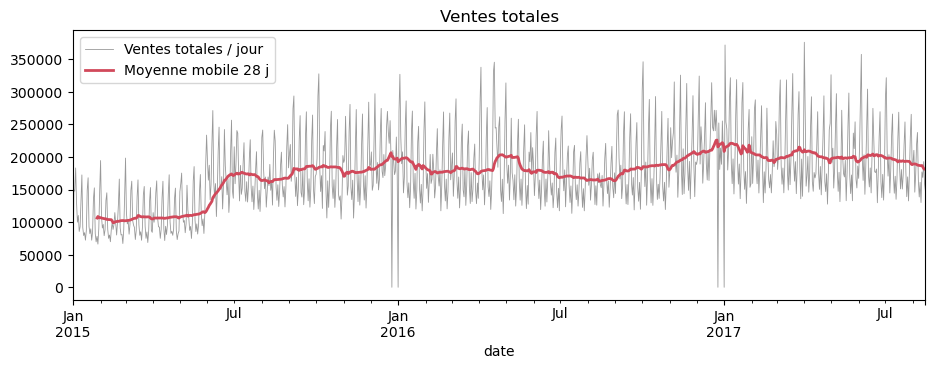

In [13]:
total = df.groupby("date")["sales"].sum()
ax = total.plot(figsize=(11, 3.5), lw=0.6, color="#999", label="Ventes totales / jour")
total.rolling(28).mean().plot(ax=ax, lw=2, color="#d1495b", label="Moyenne mobile 28 j")
ax.legend(); ax.set_title("Ventes totales"); plt.show()

## 2. Saisonnalité hebdomadaire et annuelle
Si le profil hebdo est marqué, des décalages multiples de 7 seront très informatifs.

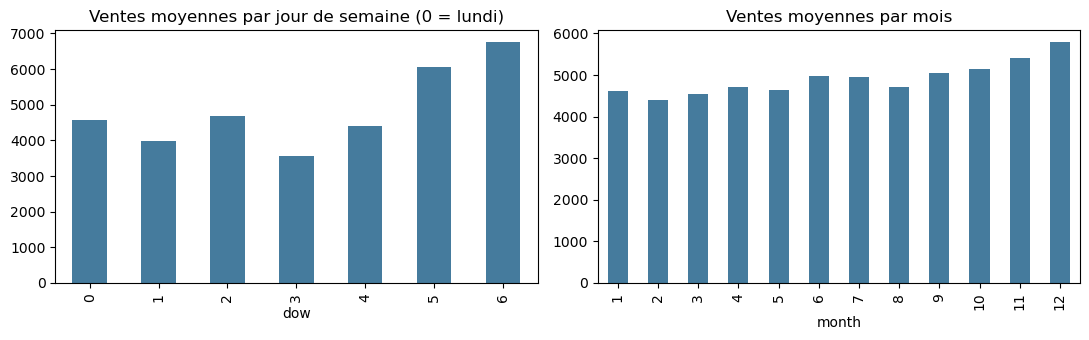

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
d = df.assign(dow=df.date.dt.dayofweek, month=df.date.dt.month)
d.groupby("dow")["sales"].mean().plot.bar(ax=axes[0], color="#457b9d"); axes[0].set_title("Ventes moyennes par jour de semaine (0 = lundi)")
d.groupby("month")["sales"].mean().plot.bar(ax=axes[1], color="#457b9d"); axes[1].set_title("Ventes moyennes par mois")
plt.tight_layout(); plt.show()

## 3. Effet des promotions

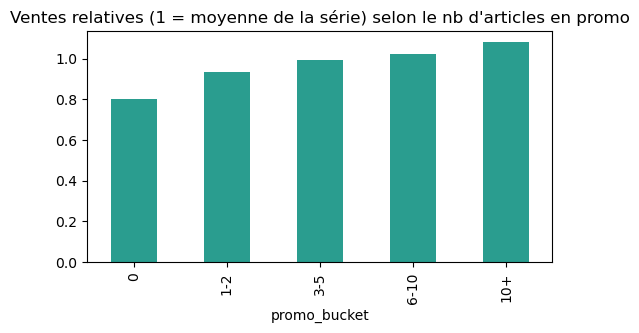

In [15]:
p = df.assign(promo_bucket=pd.cut(df.onpromotion, [-1, 0, 2, 5, 10, 1e9], labels=["0", "1-2", "3-5", "6-10", "10+"]))
# on compare chaque série à son propre niveau moyen pour neutraliser la taille du magasin
p["rel"] = p["sales"] / p.groupby(KEY)["sales"].transform("mean")
p.groupby("promo_bucket", observed=True)["rel"].mean().plot.bar(color="#2a9d8f", figsize=(6, 3))
plt.title("Ventes relatives (1 = moyenne de la série) selon le nb d'articles en promo"); plt.show()

## 4. Jours fériés, veilles et lendemains

In [16]:
h = df.assign(rel=df["sales"] / df.groupby(KEY)["sales"].transform("mean"))
h["type"] = np.select([h.date.isin(holidays), (h.date + pd.Timedelta(days=1)).isin(holidays), (h.date - pd.Timedelta(days=1)).isin(holidays)],
                      ["férié", "veille", "lendemain"], "jour ordinaire")
h.groupby("type")["rel"].mean().round(3)

type
férié             1.085
jour ordinaire    0.992
lendemain         1.042
veille            0.941
Name: rel, dtype: float64

## 5. Zéros et ruptures
Des zéros isolés = probables ruptures (la demande réelle est censurée) ; des zéros durables = produit non vendu / magasin fermé.

In [17]:
zeros = df.assign(z=df.sales.eq(0)).groupby(KEY)["z"].mean().sort_values(ascending=False)
print("Part de jours à zéro par série (top 10) :"); zeros.head(10).round(3)

Part de jours à zéro par série (top 10) :


store_nbr  family      
47         PRODUCE         0.015
3          PRODUCE         0.011
46         PRODUCE         0.010
49         PRODUCE         0.009
44         PRODUCE         0.006
45         PRODUCE         0.006
46         GROCERY I       0.005
47         BEVERAGES       0.005
           BREAD/BAKERY    0.005
           CLEANING        0.005
Name: z, dtype: float64

## 6. Décomposition STL d'une série (tendance / saisonnalité 7 j / résidu)

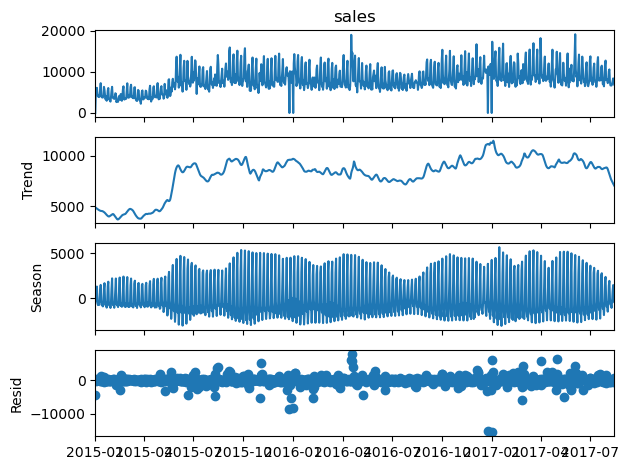

In [18]:
s = df[(df.store_nbr == df.store_nbr.iloc[0]) & (df.family == df.family.iloc[0])].set_index("date")["sales"]
STL(s, period=7, robust=True).fit().plot(); plt.show()

## 7. Autocorrélation : justification des décalages
Les pics à 7, 14, 21, 28 confirment l'intérêt des décalages hebdomadaires ; un pic à 364 justifie le décalage annuel.

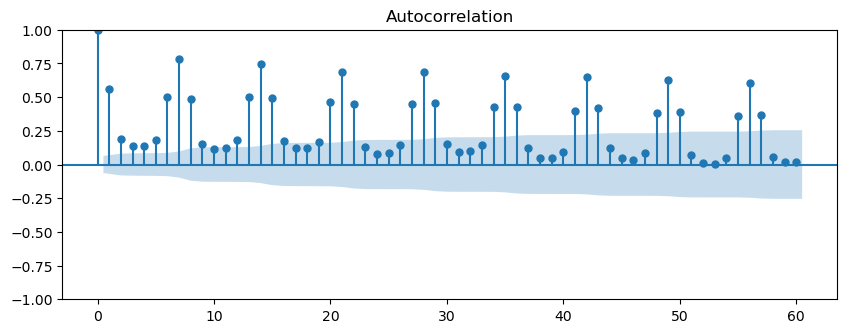

In [19]:
fig, ax = plt.subplots(figsize=(10, 3.5)); plot_acf(s, lags=60, ax=ax); plt.show()

## 8. Conclusions (à rédiger après exécution sur Favorita)

- Saisonnalité hebdo : …
- Effet promo : …
- Jours fériés : …
- Qualité des données (zéros, ruptures) : …
- Implications pour les features et la validation : …